# Projeto de Previsão de Preços de Casas na Califórnia com Decision Tree

Este projeto tem como objetivo desenvolver um modelo preditivo para estimar os preços medianos de imóveis na Califórnia utilizando o algoritmo de Árvore de Decisão (Decision Tree Regressor). 

O dataset utilizado é o **California Housing Dataset**, que contém informações sobre características de bairros e residências que influenciam o valor dos imóveis.

Este notebook seguirá as etapas de exploração dos dados, pré-processamento, construção e avaliação do modelo, além de tuning de hiperparâmetros e interpretação dos resultados.

# 1. BIBLIOTECAS:

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

# 2. DATASET:

In [3]:
# IMPORTAR O DATASET:
from sklearn.datasets import fetch_california_housing

# CARREGAR O DATASET:
df = fetch_california_housing(as_frame=True).frame

In [4]:
# 5 PRIMEIRAS LINHAS DO DATAFRAME:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# INFORMAÇÕES BÁSICAS DO DATASET:
print("📊 INFORMAÇÕES BÁSICAS DO DATASET")
print("="*50)

print(f"\n Shape do dataset: {df.shape}")
print(f"   • {df.shape[0]} registros")
print(f"   • {df.shape[1]} colunas")

print(f"\n Tipos de dados:")
print(df.dtypes)

print(f"\n Informações gerais:")
print(df.info())

print(f"\n Valores nulos por coluna:")
print(df.isnull().sum())

📊 INFORMAÇÕES BÁSICAS DO DATASET

 Shape do dataset: (20640, 9)
   • 20640 registros
   • 9 colunas

 Tipos de dados:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

 Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

 Valores nulos por colu

# 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA):

In [6]:
# MEDIDAS DESCRITIVAS:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


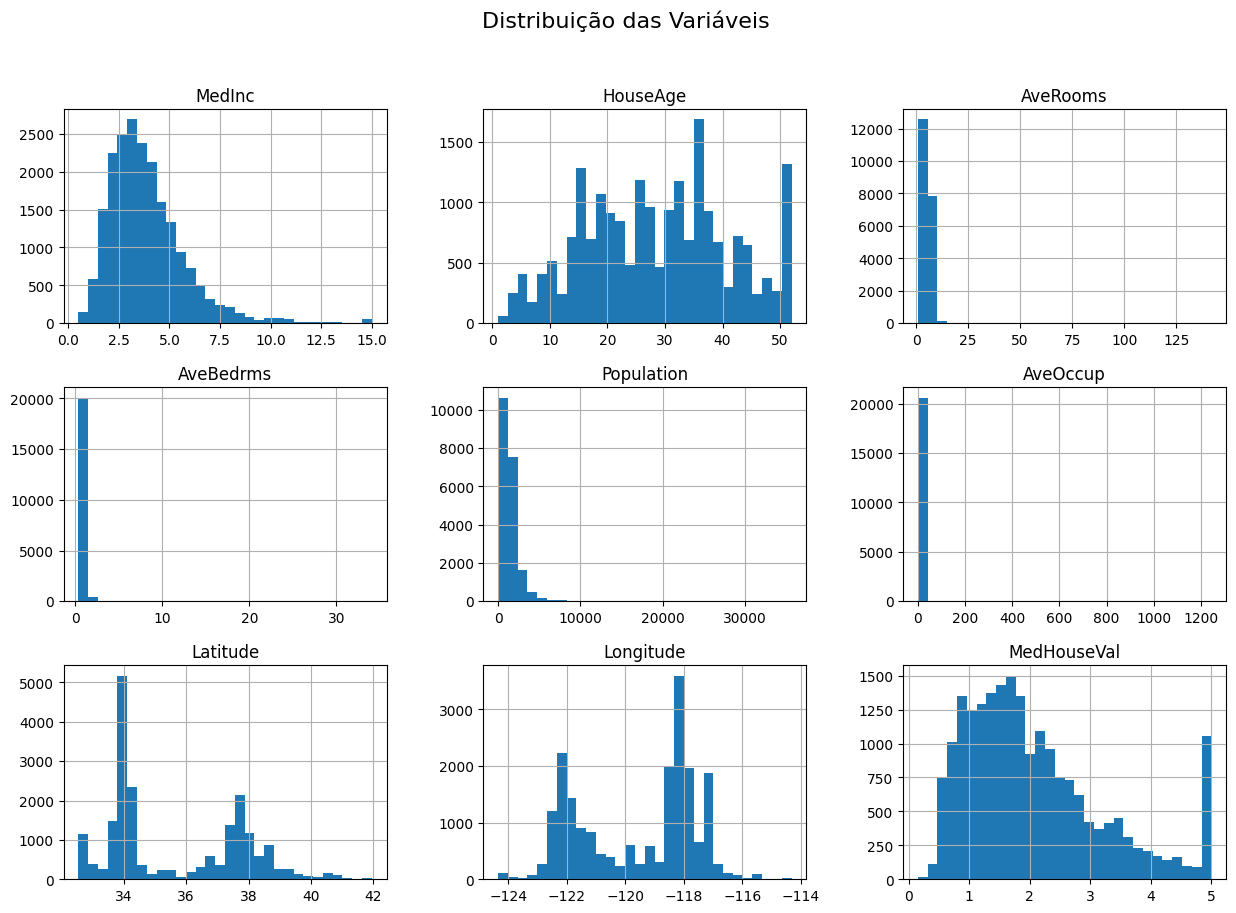

In [7]:
df.hist(bins=30, figsize=(15,10))
plt.suptitle("Distribuição das Variáveis", fontsize=16)
plt.show()

# 4. PRÉ-PROCESSAMENTO DOS DADOS:

## Pré-processamento dos dados

Nesta etapa, faremos a separação dos dados em conjuntos de treino e teste, para garantir uma avaliação imparcial do modelo posteriormente.

Também aplicaremos a padronização das variáveis, com o uso do `StandardScaler`, para que todas as features estejam na mesma escala, melhorando o desempenho do modelo.

A divisão será feita com 80% dos dados para treino e 20% para teste.

In [8]:
# DEFINIR TARGET E FEATURES:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [9]:
# SPLIT DE TREINO E TESTE:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# ESCALONAMENTO DOS DADOS:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# DIMENSÕES DOS CONJUNTOS DE TREINO E TESTE:
print(f'Dimensões treino (X, y): {X_train_scaled.shape}, {y_train.shape}')
print(f'Dimensões teste (X, y): {X_test_scaled.shape}, {y_test.shape}')

Dimensões treino (X, y): (16512, 8), (16512,)
Dimensões teste (X, y): (4128, 8), (4128,)


# 5. MODELAGEM - ÁRVORE DE DECISÃO:

In [13]:
# CRIAR E TREINAR O MODELO:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(random_state=42)

In [14]:
# REALIZAR PREDIÇÕES:
y_pred = model.predict(X_test_scaled)

## 5.1. MÉTRICAS DO MODELO:

In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 0.703
R²: 0.623


### Métricas de avaliação: RMSE e R²

Após treinar o modelo de árvore de decisão, utilizamos as seguintes métricas para avaliar seu desempenho:

- **RMSE (Root Mean Squared Error)**: Mede o erro médio das previsões em relação aos valores reais. Quanto menor o RMSE, melhor o modelo está aproximando os preços das casas. No nosso caso, o RMSE ficou em torno de 0.703.
- **R² (Coeficiente de Determinação)**: Indica o quanto das variações no valor dos imóveis são explicadas pelo modelo. Varia de 0 a 1, sendo que valores próximos de 1 indicam previsões mais ajustadas. O resultado de 0.623 significa que o modelo explicou cerca de 62% da variabilidade dos preços no conjunto de teste.

Essas duas métricas ajudam a comparar e justificar ganhos ao realizar ajustes no modelo, além de facilitar o entendimento sobre o quão eficiente está a predição.

# 6. AJUSTES DOS HIPERPARÂMETROS:

## Tuning de hiperparâmetros com GridSearchCV

Para melhorar a performance do nosso modelo, vamos realizar uma busca de hiperparâmetros utilizando o `GridSearchCV`. Os hiperparâmetros mais relevantes para o Decision Tree Regressor são a profundidade máxima da árvore (`max_depth`), o número mínimo de amostras para dividir um nó (`min_samples_split`) e o número mínimo de amostras por folha (`min_samples_leaf`).

A busca será feita sobre diferentes combinações desses hiperparâmetros e avaliada pela métrica de RMSE (erro quadrático médio).


In [18]:
# HIPERPARÂMETROS PARA AJUSTE:
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [20]:
# INSTANCIANDO O MODELO BASE:
base_tree = DecisionTreeRegressor(random_state=42)

# GRIDSHEARCH:
grid_search = GridSearchCV(base_tree, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

In [21]:
# MELHORES VALORES DOS HIPERPARÂMETROS:
print("Melhores parâmetros:", grid_search.best_params_)

Melhores parâmetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [22]:
# PREDIÇÕES COM O MELHOR MODELO:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

In [24]:
# MÉTRICAS DO MODELO AJUSTADO:
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f'RMSE (melhor modelo): {rmse_best:.3f}')
print(f'R² (melhor modelo): {r2_best:.3f}')

RMSE (melhor modelo): 0.639
R² (melhor modelo): 0.689


### Interpretação dos resultados do tuning

Após realizar o ajuste de hiperparâmetros com o GridSearchCV, observamos uma melhora nos resultados do nosso modelo Decision Tree Regressor:

- **RMSE caiu de 0.703 para 0.639**, indicando menor erro médio nas previsões dos preços das casas.
- **R² aumentou de 0.623 para 0.689**, o que significa que o modelo agora representa melhor a variabilidade dos preços no conjunto de teste.

Essas melhorias aconteceram graças à escolha de hiperparâmetros mais adequados (`max_depth`, `min_samples_leaf`, `min_samples_split`), que ajudaram a trabalhar o equilíbrio entre ajuste do modelo e sua capacidade de generalização.

A aplicação do tuning evidencia a importância de testar diferentes configurações, validando sempre com conjuntos de dados separados, para obter o melhor desempenho possível do modelo.

# 7. ANÁLISE VISUAL DA ÁRVORE DE DECISÃO:

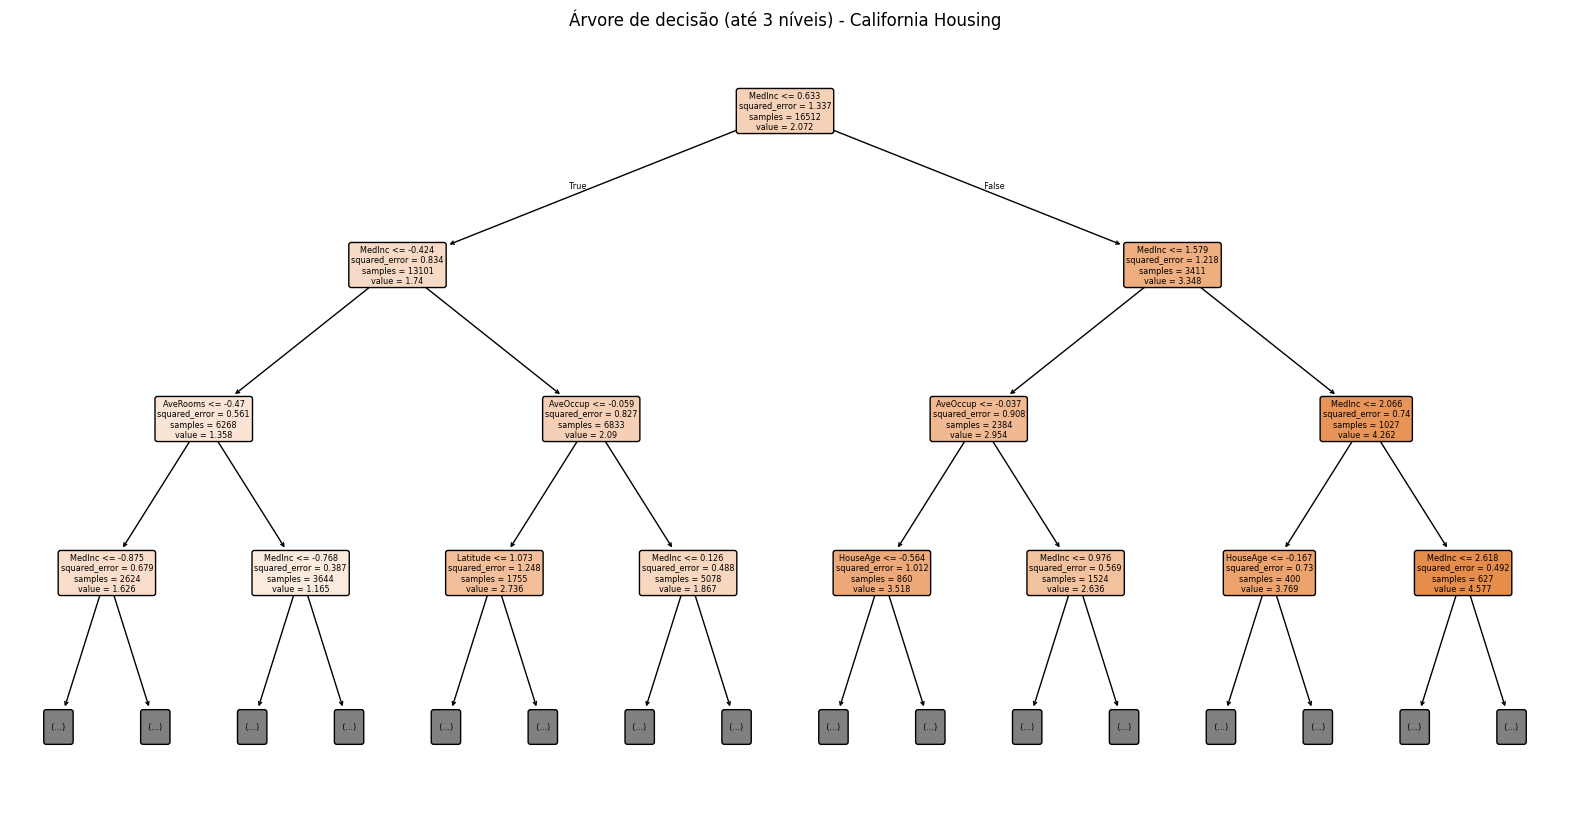

In [27]:
# 3 PRIMEIROS NÍVEIS DA ÁRVORE DE DECISÃO:
housing = fetch_california_housing()
plt.figure(figsize=(20,10))
plot_tree(best_model, feature_names=housing.feature_names, filled=True, rounded=True, max_depth=3)
plt.title('Árvore de decisão (até 3 níveis) - California Housing')
plt.show()

In [29]:
# IMPORTÂNCIA DAS VARIÁVEIS:
importances = pd.Series(best_model.feature_importances_, index=housing.feature_names).sort_values(ascending=False)
print("Importância das variáveis:")
importances

Importância das variáveis:


MedInc        0.617018
AveOccup      0.131007
Latitude      0.079174
Longitude     0.065475
HouseAge      0.044928
AveRooms      0.037535
Population    0.013128
AveBedrms     0.011734
dtype: float64

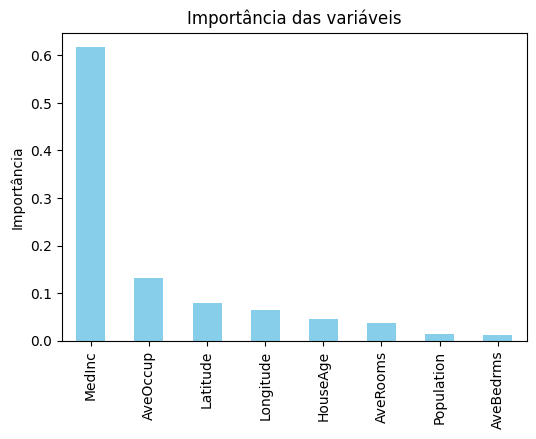

In [32]:
# VISUALIZAÇÃO DA IMPORTÂNCIA DAS VARIÁVEIS:
importances.plot(kind='bar', color='skyblue', figsize=(6,4), title='Importância das variáveis')
plt.ylabel('Importância')
plt.show()

### Interpretação da importância das variáveis

A análise da importância das variáveis revela que **MedInc (renda média do bairro)** é o atributo que mais impacta no preço dos imóveis, sendo responsável por mais de 60% das decisões do modelo. Isso reforça a relação direta entre renda local e valorização imobiliária.

Outros fatores, como número médio de ocupantes por residência, localização geográfica (latitude/longitude) e idade média das casas, também aparecem como relevantes, porém em menor escala.

Variáveis como `Population` e `AveBedrms` se mostraram pouco impactantes para previsão, sugerindo que podem ser menos relevantes em modelos futuros ou descartadas em processos avançados de feature selection.

# 8. CONCLUSÃO:

## Conclusão e aprendizados

Neste projeto, desenvolvemos um modelo preditivo baseado em árvore de decisão para estimar o preço mediano de casas na Califórnia, utilizando um pipeline completo em Python com scikit-learn.

Principais aprendizados:
- **Exploração dos dados** revelou forte influência da renda média do bairro sobre os preços dos imóveis.
- **Modelo inicial** apresentou desempenho razoável, com RMSE de 0.703 e R² de 0.623.
- **Tuning dos hiperparâmetros** elevou o desempenho do modelo para RMSE de 0.639 e R² de 0.689, evidenciando a importância da validação e ajustamento do modelo.
- **Interpretação visual** permitiu entender os splits e destacar características relevantes, aumentando a transparência do modelo.

Como próximas etapas, pode-se testar outros algoritmos (Random Forest, XGBoost), incluir novas variáveis ou realizar análise residual para aprofundar a compreensão dos erros modelados.